In [52]:
# Load packages
from pathlib import Path
import os
import re
import sys
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyteomics import achrom
# Importantly, import kardemumma :)
import kardemumma as kdm

In [53]:

# Skyline data path
skyline_path = "data/DA4000/Kardemumma_v3_sept14.csv"

# Import skyline data (includes column "Isotope Label Type" from Precursor)
skyline_importer = kdm.ImportSkylineFile(skyline_path)
skyline_data = skyline_importer.import_skyline_file()

Importing Skyline file: data/DA4000/Kardemumma_v3_sept14.csv


/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/importer.py:218: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(self.file_path)


File data/DA4000/Kardemumma_v3_sept14.csv is valid.


In [54]:
# **SDRF**
sdrf_path = 'data/DA4000/20260917_DA4.5K.sdrf.tsv'

# Valdate sdrf fasta_file
kdm.validate_sdrf(sdrf_path)
kdm.readout_ms_type(sdrf_path)

# Import SDRF file for this project
sdrf_data = kdm.ImportSDRFFile(sdrf_path)
sdrf_data_file = sdrf_data.import_sdrf_file()



Type(s) of MS experiment(s) in SDRF: NT=Parallel Reaction Monitoring;AC=MS:1002956
Importing SDRF file: data/DA4000/20260917_DA4.5K.sdrf.tsv


In [55]:
# Valdate sdrf 
kdm.validate_sdrf(sdrf_path)

(True, 'Everything seems to be fine. Well done.')

In [56]:
# Print out what Peptide Sequence iRT

kdm.get_irt_peptides(skyline_data)

Checking if the peptides are from Biognosys...
Not matched: DLQAQVVESAK, NLINNAK, ELDKYGVSDYYK, SIELAEAK, ELDKYGVSDYHK, SQTPAEDTVK, YGVSDYHK, TVEGVKDLQAQVVESAK, ISEATDGLSDFLK, YGVSDYYK
Number of peptides not matching Biognosys: 10

Number of iRT peptides: 10
iRT peptides: ['ELDKYGVSDYHK', 'YGVSDYHK', 'NLINNAK', 'TVEGVKDLQAQVVESAK', 'DLQAQVVESAK', 'ISEATDGLSDFLK', 'SQTPAEDTVK', 'SIELAEAK', 'ELDKYGVSDYYK', 'YGVSDYYK']



['ELDKYGVSDYHK',
 'YGVSDYHK',
 'NLINNAK',
 'TVEGVKDLQAQVVESAK',
 'DLQAQVVESAK',
 'ISEATDGLSDFLK',
 'SQTPAEDTVK',
 'SIELAEAK',
 'ELDKYGVSDYYK',
 'YGVSDYYK']

In [57]:
# Checking possible QC samples from Skyline results

qc_samples = skyline_importer.suggest_qc_samples(skyline_data)
# skyline_checker = CheckSkylineFile(skyline_path)

# Suggest qc samples

print(qc_samples)


Number of possible QC samples: 0
Possible QC samples: []
Consider removing these QC samples before further analysis.
[]


In [58]:
# Remove QC samples from skyline_data
skyline_data = kdm.remove_qc_samples(skyline_data, qc_samples)


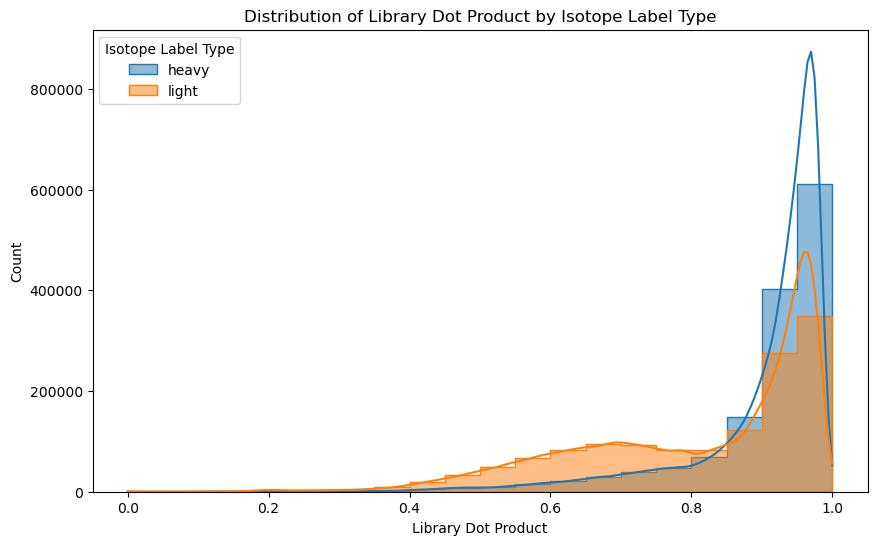

In [59]:
kdm.plot_library_dot_product_distribution(skyline_data)

In [60]:
skyline_clean = kdm.filter_library_dot_product(skyline_data, threshold=0.8)


Isotope Label Type
heavy    1195208
light     829706
Name: count, dtype: int64


In [61]:
# Summarise each peptide to count how many heavy or light signals are present in skyline_pivot
peptide_counts = kdm.summarise_peptide_counts(skyline_clean)


In [62]:
report_summary, peptide_list = kdm.report_peptide_protein_summary(peptide_counts)

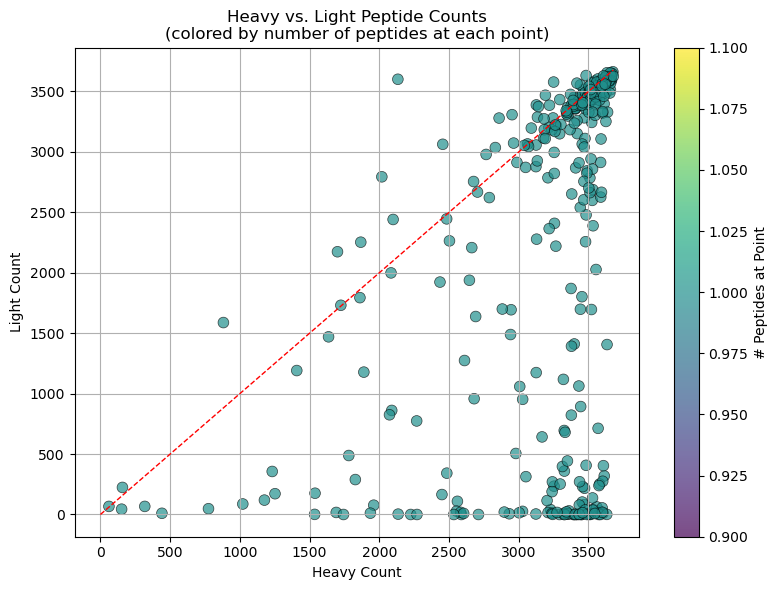

In [63]:
kdm.plot_heavy_light_scatter(peptide_counts)

In [64]:
clustered_peptide_counts, cutoff = kdm.cluster_abundant_peptides(peptide_counts)
print(f"Suggested cutoff (HDBSCAN abundant cluster): {cutoff}")

filtered_peptide_counts = kdm.filter_peptide_counts(
    peptide_counts, light_cutoff=cutoff["light_count"], heavy_cutoff=cutoff["heavy_count"]
) 

filtered_peptide_counts.head()

Suggested cutoff (HDBSCAN abundant cluster): {'heavy_count': 3259, 'light_count': 3259}


,Protein Name,Peptide,heavy_count,light_count
0,QR0140840_SERPINA6|P08185,MNTVIAALSR,3614,3578
1,QR0140840_SERPINA6|P08185,WSAGLTSSQVDLYIPK,3563,3529
2,QR0252445_ITIH3|Q06033,ALDLSLK,3502,3464
3,QR0260124_APOA4|P06727,DKVNSFFSTFK,3597,3545
4,QR0260124_APOA4|P06727,ISASAEELR,3608,3629


In [65]:
# Manual cutoff override -- uncomment and edit if the HDBSCAN-suggested
# cutoff above isn't right for this dataset, then re-run this cell.

# light_cutoff = 3000                            # min light_count to keep a peptide
# heavy_cutoff = 3000                             # min heavy_count to keep a peptide
# filtered_peptide_counts = kdm.filter_peptide_counts(
#     peptide_counts, light_cutoff=light_cutoff, heavy_cutoff=heavy_cutoff
# )                                                # re-filter peptide_counts with the manual cutoff
# filtered_peptide_counts.head()                   # preview the manually filtered result

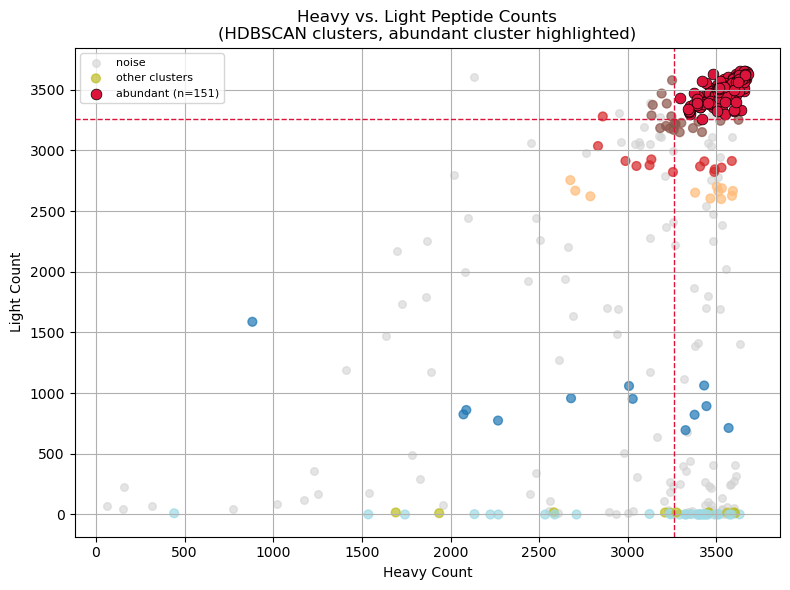

In [66]:
kdm.plot_heavy_light_clusters(clustered_peptide_counts)

In [67]:
selected_peptides_report, selected_peptides = kdm.report_peptide_protein_summary(filtered_peptide_counts)

In [68]:
# from kardemumma.importer import MergeFiles

skyline_merge_obj = kdm.MergeFiles(skyline_data, sdrf_data_file, selected_peptides)
skyline_merge = skyline_merge_obj.merge_files()

Sample names in Skyline but not in SDRF (291).
----------------------------------------
Sample names in SDRF but not in Skyline (223).


In [69]:
skyline_pool = skyline_merge_obj.select_pool_data(label_col='characteristics[Sample]', pool_label='PlasmaPool')
# Need to check printing????

Summary of samples per plate:
Plate Plate_1: 5 unique comment[data file] names
Plate Plate_11: 5 unique comment[data file] names
Plate Plate_12: 5 unique comment[data file] names
Plate Plate_13: 4 unique comment[data file] names
Plate Plate_14: 5 unique comment[data file] names
Plate Plate_15: 5 unique comment[data file] names
Plate Plate_16: 4 unique comment[data file] names
Plate Plate_18: 5 unique comment[data file] names
Plate Plate_19: 5 unique comment[data file] names
Plate Plate_2: 5 unique comment[data file] names
Plate Plate_20: 4 unique comment[data file] names
Plate Plate_21: 5 unique comment[data file] names
Plate Plate_22: 5 unique comment[data file] names
Plate Plate_23: 5 unique comment[data file] names
Plate Plate_24: 4 unique comment[data file] names
Plate Plate_25: 5 unique comment[data file] names
Plate Plate_26: 5 unique comment[data file] names
Plate Plate_27: 5 unique comment[data file] names
Plate Plate_28: 5 unique comment[data file] names
Plate Plate_29: 5 uniq

In [70]:
skyline_pool.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
0,741.3798++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,15.34,2,AAVYHHFISDGVR,4.5803E+4,0.9639,NaN,0.9007,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
1,736.3757++,04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,15.34,2,AAVYHHFISDGVR,4.5803E+4,0.9639,0.8907,0.8859,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
2,539.9587+++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,13.93,3,AAVYHHFISDGVRK,1.9579E+5,0.8795,NaN,0.9136,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
3,533.9512+++,04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,13.93,3,AAVYHHFISDGVRK,1.9579E+5,0.8795,0.9794,0.9138,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
4,664.8145++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,16.87,2,ACIPTGPYPCGK,5.1914E+4,0.7520,NaN,0.9224,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random


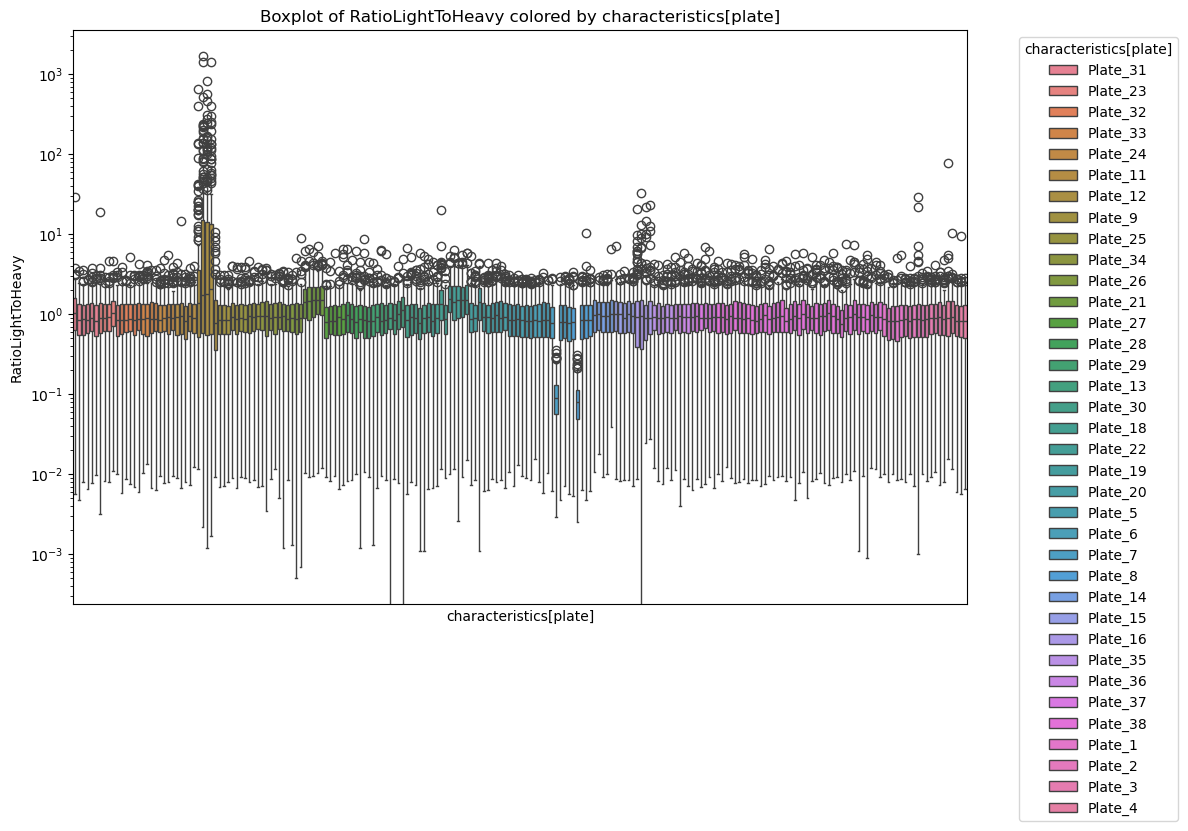

In [71]:
# Plot log_ratio of each sample in boxplot, colored by plate, but x-axis is Replicate, sorted by plate (though x labels are hidden).
kdm.plot_pool_boxplot(skyline_pool)


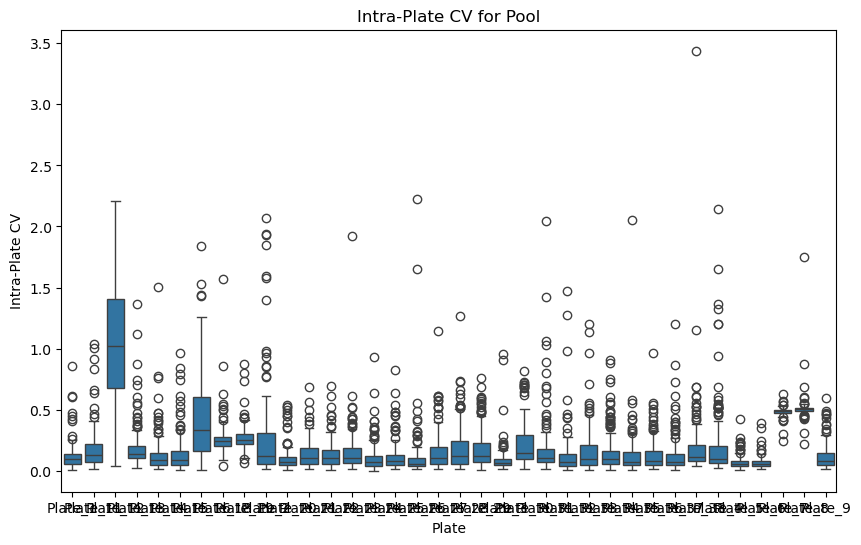

In [72]:
# Calculate intra-plate CV

peptide_plate_stats = kdm.calculate_intra_plate_cv(skyline_pool, col_name='characteristics[plate]')
kdm.plot_intra_plate_cv_stats(peptide_plate_stats, col_name='characteristics[plate]')

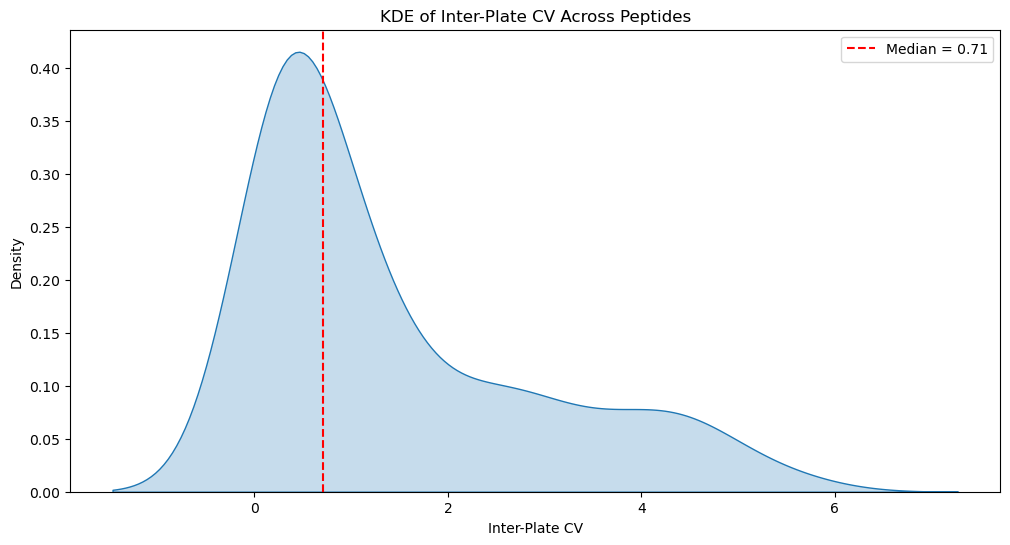

In [73]:
interplate_cv = kdm.calculate_inter_plate_cv(peptide_plate_stats)
kdm.plot_inter_plate_cv_kde(interplate_cv)

In [74]:
interplate_cv.head()

,Peptide Sequence,grand_mean,between_plate_sd,inter_plate_cv
0,GYTLADNGK,0.529940,0.077017,0.145331
1,SWFEPLVEDMQR,0.838772,0.136797,0.163093
2,KWQEEMELYR,1.789703,0.326037,0.182174
3,MREWFSETFQK,1.811097,0.331129,0.182833
4,IASFSQNCDIYPGK,1.393584,0.259012,0.185861


In [75]:
# Print interplate_cv froom low to high
print('This is the interplate_cv from low to high:')
print(interplate_cv[interplate_cv['inter_plate_cv'] < 0.1])

This is the interplate_cv from low to high:
Empty DataFrame
Columns: [Peptide Sequence, grand_mean, between_plate_sd, inter_plate_cv]
Index: []


Total peptides: 152
  CV < 10%: 0 peptides
  CV < 20%: 15 peptides


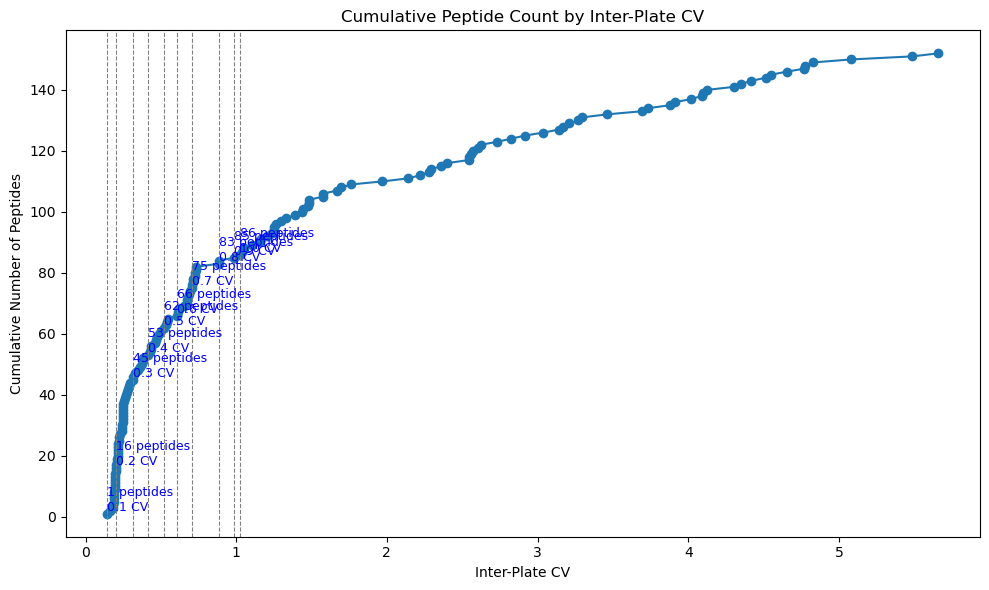

In [76]:
kdm.plot_cumulative_peptide_count_by_cv(interplate_cv)

In [77]:
selected_peptides = kdm.get_lowest_cv_peptides(interplate_cv, 17)
selected_peptides

array(['GYTLADNGK', 'SWFEPLVEDMQR'], dtype=object)

In [78]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) 
# using only peptides in the top 10% lowest inter-plate CV for normalization

pool_selected_df = skyline_pool[skyline_pool['Peptide Sequence'].isin(selected_peptides)]

# Remove bad plasmapool 

# bad_pools = [
#        'PRM_20260422_DA_4K_B2_Plate_7_C1.raw',
#        'PRM_20260422_DA_4K_B2_Plate_8_B8.raw']


# # Remove bad peptides 
# bad_peptides = ['ESDTSYVSLK', 'VTLNGVPAQPLGPR', 'FSIEGSYQLEK', 'GLLSGWAR']

# # Filter bad_pools from pool_selected_df
# pool_selected_df = pool_selected_df[~pool_selected_df['File Name'].isin(bad_pools)]

# # Filter bad_peptides from pool_selected_df
# pool_selected_df = pool_selected_df[~pool_selected_df['Peptide Sequence'].isin(bad_peptides)]

# Filter pool_data to include only those peptides for normalization calculation
pool_selected_df

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
84,473.7396++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,13.49,2,GYTLADNGK,4.8834E+4,0.4985,NaN,0.9533,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
85,469.7325++,04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,13.49,2,GYTLADNGK,4.8834E+4,0.4985,0.9389,0.9504,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
212,773.8653++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,28.31,2,SWFEPLVEDMQR,1.4623E+4,1.4778,NaN,0.6293,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
213,768.8612++,04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,28.31,2,SWFEPLVEDMQR,1.4623E+4,1.4778,0.7389,0.5117,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
388,473.7396++ (heavy),04_DA4K_B9_P31_C3,PRM_20260804_DA4K_B9_P31_C3.raw,13.38,2,GYTLADNGK,7.1329E+4,0.5117,NaN,0.9772,...,not available,not available,not available,not available,not available,NaN,NaN,not available,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63445,768.8612++,DA_4K_B1_Plate4_G1,PRM_20260410_DA_4K_B1_Plate4_G1.raw,26.46,2,SWFEPLVEDMQR,6.6088E+6,0.8228,0.9884,0.9818,...,not available,not available,not available,not available,not available,NaN,Healthy,not available,1.0,NaN
63620,473.7396++ (heavy),DA_4K_B1_Plate4_G4,PRM_20260410_DA_4K_B1_Plate4_G4.raw,13.16,2,GYTLADNGK,4.6493E+5,0.4429,NaN,0.9721,...,not available,not available,not available,not available,not available,NaN,Healthy,not available,1.0,NaN
63621,469.7325++,DA_4K_B1_Plate4_G4,PRM_20260410_DA_4K_B1_Plate4_G4.raw,13.16,2,GYTLADNGK,4.6493E+5,0.4429,0.9380,0.9409,...,not available,not available,not available,not available,not available,NaN,Healthy,not available,1.0,NaN
63748,773.8653++ (heavy),DA_4K_B1_Plate4_G4,PRM_20260410_DA_4K_B1_Plate4_G4.raw,26.36,2,SWFEPLVEDMQR,5.0969E+6,0.8322,NaN,0.9676,...,not available,not available,not available,not available,not available,NaN,Healthy,not available,1.0,NaN


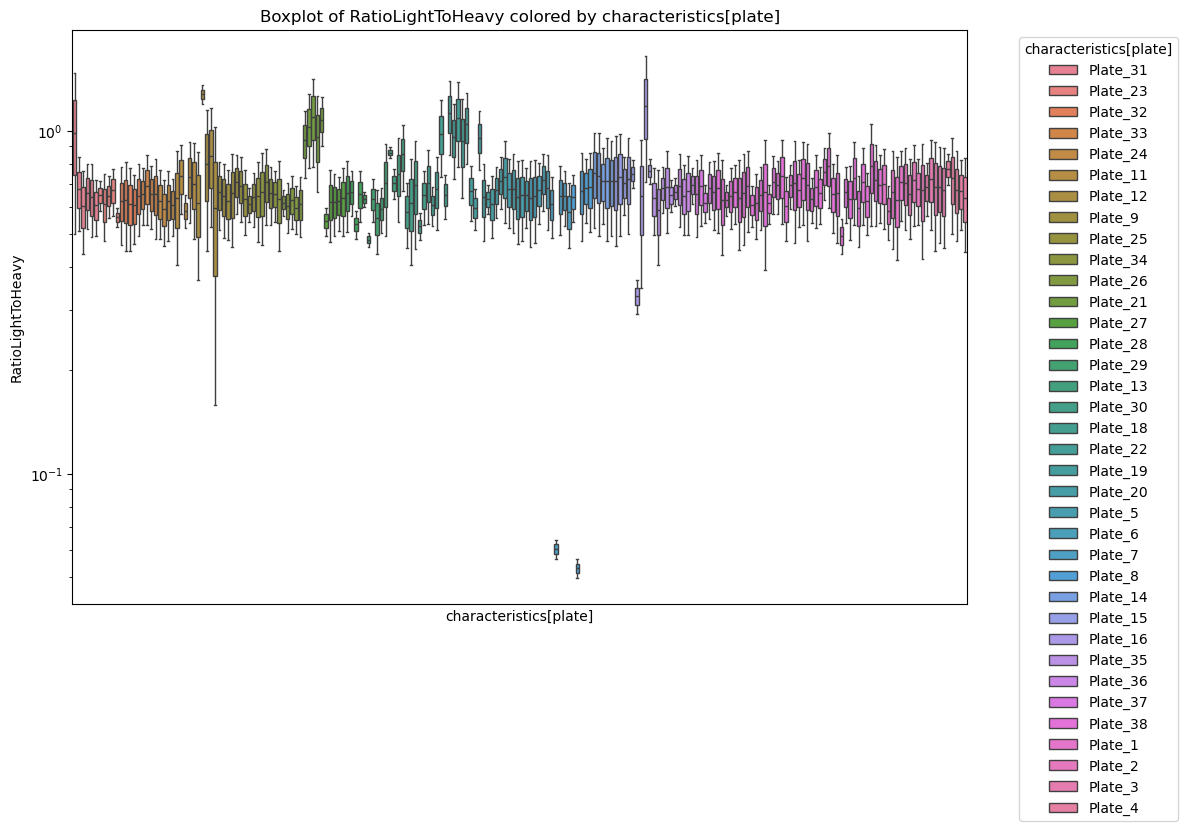

In [79]:
kdm.plot_pool_boxplot(pool_selected_df)

In [80]:
plate_factor_table, conversion_factors, model = kdm.get_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=False  )

Conversion factors: {'Plate_1': 1.1034315312398837, 'Plate_11': 1.1158945817646095, 'Plate_12': 0.7194343306421825, 'Plate_13': 0.8479383046209341, 'Plate_14': 0.9563021673563863, 'Plate_15': 0.9083883003531213, 'Plate_16': 0.9668817814339409, 'Plate_18': 0.9608851927549511, 'Plate_19': 0.996418913980852, 'Plate_2': 1.005457227138643, 'Plate_20': 1.0258841234010532, 'Plate_21': 0.6650731707317074, 'Plate_22': 0.6667970851469652, 'Plate_23': 1.1580735581415103, 'Plate_24': 1.1254746574211656, 'Plate_25': 1.1137069106355169, 'Plate_26': 1.104325287542524, 'Plate_27': 1.2309498013723363, 'Plate_28': 1.150742741390952, 'Plate_29': 1.3010783471705316, 'Plate_3': 0.9951098459966427, 'Plate_30': 1.2317282500677567, 'Plate_31': 1.102450068731301, 'Plate_32': 1.101203456909781, 'Plate_33': 1.0417972033315503, 'Plate_34': 1.0432320759048128, 'Plate_35': 1.051195065535852, 'Plate_36': 1.0176145693387073, 'Plate_37': 1.0923804182357182, 'Plate_38': 1.1154381084840055, 'Plate_4': 0.8992217385569186

In [81]:
plate_factor_table.head()

,characteristics[plate],plate_median,correction_factor
0,Plate_1,0.61780,1.103432
1,Plate_11,0.61090,1.115895
2,Plate_12,0.94755,0.719434
3,Plate_13,0.80395,0.847938
4,Plate_14,0.71285,0.956302


/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:694: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


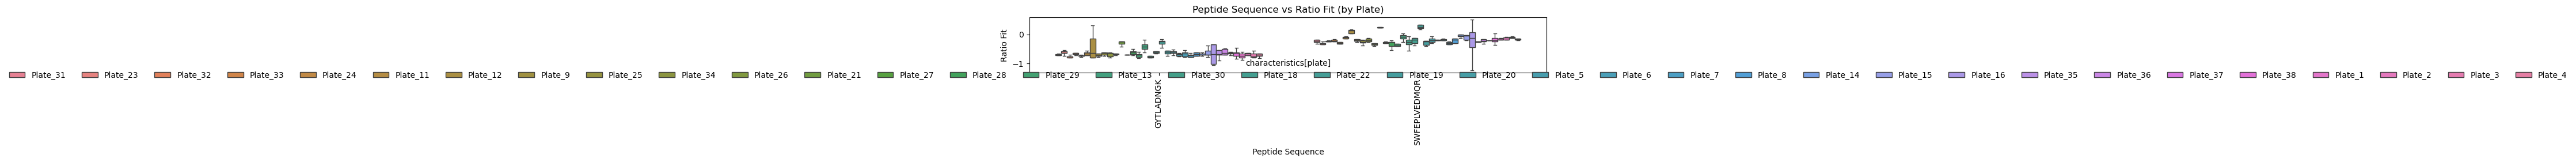

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [82]:
kdm.plot_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=True  )

In [83]:
# Use the adjust_ratio_by_plate function above to add RatioLightToHeavy_adj to skyline_merge
# First, construct a Plate column of the correct type for the function
skyline_merge_adj = skyline_merge.copy()
# Remove samples from Replicate column that are in qc_samples
skyline_merge_adj = skyline_merge_adj[~skyline_merge_adj['Replicate'].isin(qc_samples)]

# Remove sampels from Plate_1 from characteristics[plate]
skyline_merge_adj = skyline_merge_adj[skyline_merge_adj['characteristics[plate]'] != 'Plate_1']


In [84]:
# Adjust ratio by conversion factor 
skyline_merge_adj = kdm.adjust_ratio_by_plate(skyline_merge_adj, conversion_factors)

skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
0,488.2589++,B2_Plate_5_A1,PRM_20260422_DA_4K_B2_Plate_5_A1.raw,13.75,2,ISASAEELR,3.2573E+7,2.521445,0.9623,0.9840,...,not available,not available,not available,not available,not available,Multiple sclerosis,Neurologic,not available,1.0,Multiple sclerosis
1,488.2589++,B2_Plate_5_A2,PRM_20260422_DA_4K_B2_Plate_5_A2.raw,13.72,2,ISASAEELR,2.0071E+7,1.493447,0.9614,0.9713,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
2,488.2589++,B2_Plate_5_A3,PRM_20260422_DA_4K_B2_Plate_5_A3.raw,13.69,2,ISASAEELR,3.9832E+7,3.917224,0.9533,0.9766,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
3,488.2589++,B2_Plate_5_A4,PRM_20260422_DA_4K_B2_Plate_5_A4.raw,13.83,2,ISASAEELR,1.8734E+7,1.501745,0.9866,0.9835,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
4,488.2589++,B2_Plate_5_A5,PRM_20260422_DA_4K_B2_Plate_5_A5.raw,13.58,2,ISASAEELR,2.7496E+7,2.507424,0.9493,0.9537,...,not available,not available,not available,not available,not available,Nonalcoholic steatohepatitis,Metabolic,not available,1.0,Nonalcoholic steatohepatitis


In [85]:
# From skyline_merge_adj, filter to pool samples
pool_data_adj = skyline_merge_adj[skyline_merge_adj['characteristics[Sample]'] != 'PlasmaPool'].copy()

# Reorder by characteristics[Plate]
pool_data_adj = pool_data_adj.sort_values(by='characteristics[plate]')

pool_data_adj.head()


,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
998166,696.8459++ (heavy),08_DA_4K_B3_Plate_11_G2,PRM_20260508_DA_4K_B3_Plate_11_G2.raw,12.92,2,HGNTDSEGIVEVK,9.7574E+5,1.244024,NaN,0.9179,...,not available,not available,not available,not available,not available,Healthy,Healthy,not available,1.0,Healthy
677923,575.6161+++,08_DA_4K_B3_Plate_11_F7,PRM_20260508_DA_4K_B3_Plate_11_F7.raw,19.81,3,GKEESLDSDLYAELR,2.7893E+6,1.583035,0.9372,0.9737,...,not available,not available,not available,not available,not available,case,NaN,not available,1.0,case
677924,575.6161+++,08_DA_4K_B3_Plate_11_F8,PRM_20260508_DA_4K_B3_Plate_11_F8.raw,16.71,3,GKEESLDSDLYAELR,7.3274E+5,1.169376,0.8927,0.7933,...,not available,not available,not available,not available,not available,Acute COVID,Infection,not available,1.0,Acute COVID
677925,575.6161+++,08_DA_4K_B3_Plate_11_F9,PRM_20260508_DA_4K_B3_Plate_11_F9.raw,19.86,3,GKEESLDSDLYAELR,3.9786E+6,1.914339,0.9513,0.9644,...,not available,not available,not available,not available,not available,Pancreatic ductal adenocarcinoma,Cancer,not available,1.0,Pancreatic ductal adenocarcinoma
677926,575.6161+++,08_DA_4K_B3_Plate_11_F10,PRM_20260508_DA_4K_B3_Plate_11_F10.raw,19.99,3,GKEESLDSDLYAELR,6.0789E+6,2.894718,0.9296,0.9643,...,not available,not available,not available,not available,not available,Vasculitis,Autoimmune,not available,1.0,Vasculitis


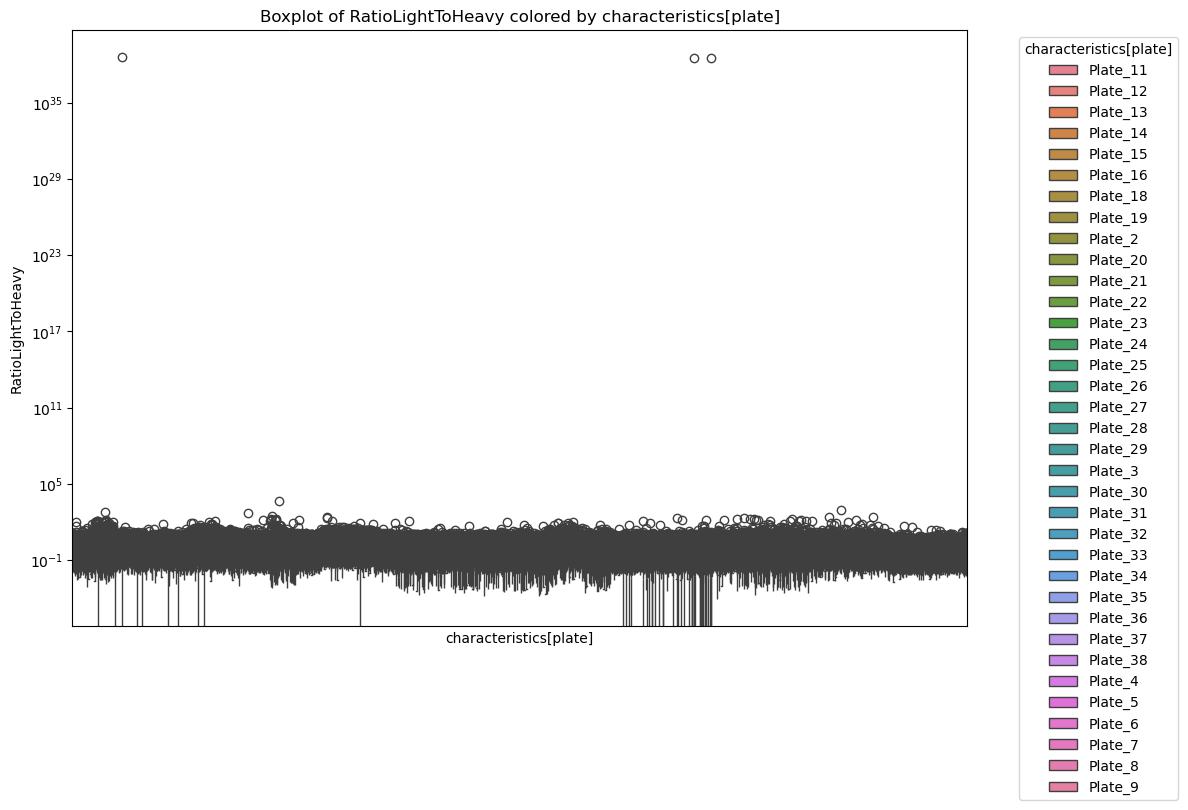

In [86]:
kdm.plot_pool_boxplot(pool_data_adj)

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:694: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


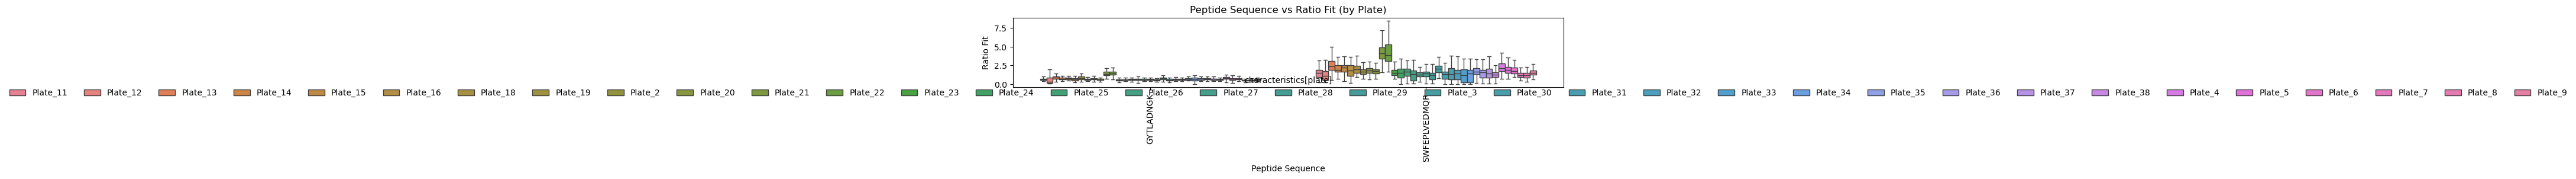

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [87]:
pool_selected_adj = pool_data_adj[pool_data_adj['Peptide Sequence'].isin(selected_peptides)]

kdm.plot_plate_conversion_factors(pool_selected_adj, col_plate='characteristics[plate]', log_transform=False  )

# SDRF metadata

Overview of metadata

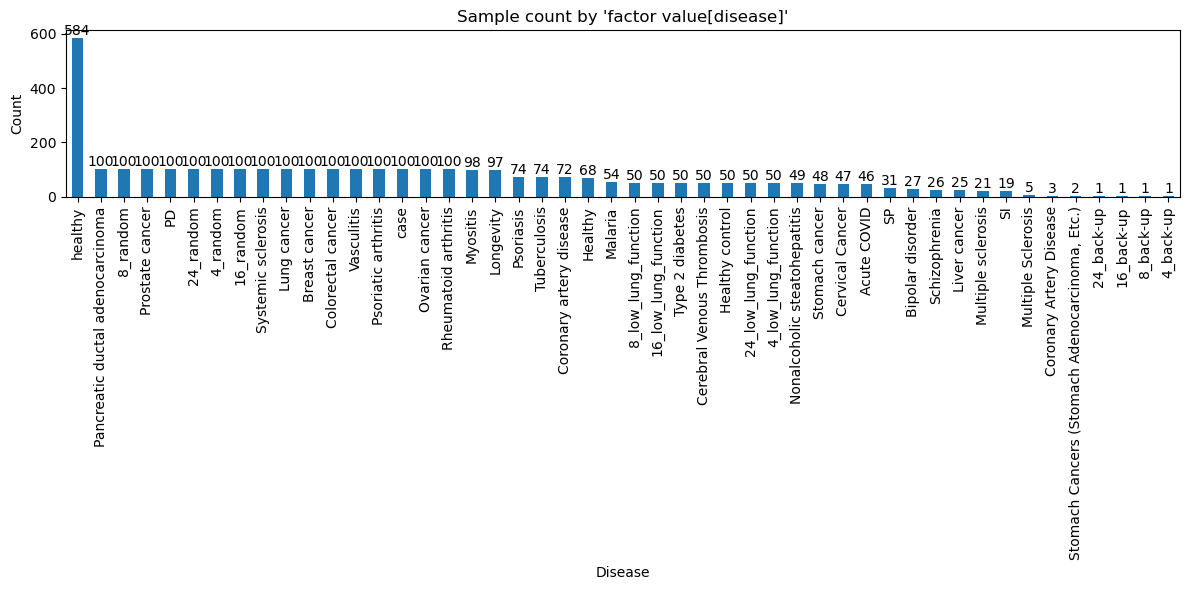

In [88]:
import matplotlib.pyplot as plt

# Make a barplot of 'factor value[disease]' column
plt.figure(figsize=(12,6))
value_counts = sdrf_data_file['factor value[disease]'].value_counts()
ax = value_counts.plot(kind='bar')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.title("Sample count by 'factor value[disease]'")
plt.tight_layout()

# Add number on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.show()

# Calculate absolute quantification

In [89]:
# Extract qRePS lot from SDRF file 
qreps_lot = sdrf_data.extract_qreps_lot_number()
# Fetch qRePS table
qreps_table = kdm.fetch_qreps_table(qreps_lot)

qreps_table.head()

qREPs lot number: 24001


,qRePS,Gene,Protein,Uniprot,Amount per well [pmol]
0,QR3140513,A1BG,Alpha-1B-glycoprotein,P04217,1.327
1,QR5000096,A2M,Alpha-2-macroglobulin,P01023,1.971
2,QR0140749,ACTN1,Alpha-actinin-1,P12814,0.157
3,QR0221144,ADA2,Adenosine deaminase 2,Q9NZK5,0.015
4,QR5000237,ADAMTS13,A disintegrin and metalloproteinase with throm...,Q76LX8,0.057


In [90]:
# Calculate absolute protein concentratio w ith default cutoffs is 1000 and 10**-3
abs_df = kdm.get_absolute_conc(qreps_table, skyline_merge_adj, ratio_cutoff_low=10**-2, ratio_cutoff_high=10**2)

Number of out of bounds ratios: 8996
Ratio cutoff low: 0.01
Ratio cutoff high: 100
Number of unique qRePS ids: 73
Number of unique Peptide Sequences: 152
Number of unique Protein Names: 73
Number of unique File Names: 3306


In [91]:
# Wide abs_df -> long: one row per peptide x sample file
abs_df_long = (
    abs_df.reset_index()
    .melt(
        id_vars=["qRePS", "Peptide Sequence", "Protein Name"],
        var_name="File Name",
        value_name="Protein conc [pmol]",
    )
    .dropna(subset=["Protein conc [pmol]"])
)

abs_df_long.head()

,qRePS,Peptide Sequence,Protein Name,File Name,Protein conc [pmol]
0,QR0140840,MNTVIAALSR,QR0140840_SERPINA6|P08185,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.1954
1,QR0140840,WSAGLTSSQVDLYIPK,QR0140840_SERPINA6|P08185,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.2855
2,QR0252445,ALDLSLK,QR0252445_ITIH3|Q06033,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.7838
3,QR0260124,DKVNSFFSTFK,QR0260124_APOA4|P06727,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.8943
4,QR0260124,ISASAEELR,QR0260124_APOA4|P06727,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.9838


In [92]:
# Join SDRF metadata on File Name (= comment[data file])
sdrf_cols = [
    "comment[data file]",
    "characteristics[disease]",
    "characteristics[disease category]",
    "characteristics[Sample ID]",
]
mapping_df = (
    sdrf_data_file[sdrf_cols]
    .drop_duplicates(subset=["comment[data file]"])
    .rename(columns={"comment[data file]": "File Name"})
)

abs_df_long = abs_df_long.merge(mapping_df, on="File Name", how="left")

unmapped = abs_df_long.loc[abs_df_long["characteristics[disease]"].isna(), "File Name"].unique()
if len(unmapped):
    print(f"Unmapped File Name ({len(unmapped)}):", sorted(unmapped)[:10], "...")

abs_df_long.head()

Unmapped File Name (206): ['PRM_20260410_DA_4K_B1_Plate2_A9.raw', 'PRM_20260410_DA_4K_B1_Plate2_D3.raw', 'PRM_20260410_DA_4K_B1_Plate2_D9.raw', 'PRM_20260410_DA_4K_B1_Plate2_E12.raw', 'PRM_20260410_DA_4K_B1_Plate2_F10.raw', 'PRM_20260410_DA_4K_B1_Plate3_A2.raw', 'PRM_20260410_DA_4K_B1_Plate3_C9.raw', 'PRM_20260410_DA_4K_B1_Plate3_D11.raw', 'PRM_20260410_DA_4K_B1_Plate3_D4.raw', 'PRM_20260410_DA_4K_B1_Plate3_G10.raw'] ...


,qRePS,Peptide Sequence,Protein Name,File Name,Protein conc [pmol],characteristics[disease],characteristics[disease category],characteristics[Sample ID]
0,QR0140840,MNTVIAALSR,QR0140840_SERPINA6|P08185,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.1954,Cerebral Venous Thrombosis,Cardiovascular,DA12887
1,QR0140840,WSAGLTSSQVDLYIPK,QR0140840_SERPINA6|P08185,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.2855,Cerebral Venous Thrombosis,Cardiovascular,DA12887
2,QR0252445,ALDLSLK,QR0252445_ITIH3|Q06033,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.7838,Cerebral Venous Thrombosis,Cardiovascular,DA12887
3,QR0260124,DKVNSFFSTFK,QR0260124_APOA4|P06727,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.8943,Cerebral Venous Thrombosis,Cardiovascular,DA12887
4,QR0260124,ISASAEELR,QR0260124_APOA4|P06727,PRM_20260410_DA_4K_B1_Plate2_A1.raw,0.9838,Cerebral Venous Thrombosis,Cardiovascular,DA12887


In [93]:
# Optional: export long table with SDRF metadata
# abs_df_long.to_csv("20260923_Martinabs_df_long.csv", index=False)

In [94]:
target_fasta = 'https://proteomedge.com/download/DE17501/DE17501_sequences.fasta'

# Read fasta file
fasta_file = kdm.fetch_fasta(qreps_lot)
fasta_file.head()

,id,sequence
0,QR0520106_CSF1R|P07333,TYRHTFTLSLPRLKPSEAGRYSFLARNPGGWRALTFELTLRYPPEV...
1,QR0280166_C1R|P00736,PNNFETTTVITVPTGYRVKLVFQQFDLEPSEGCFYDYVKISADKKS...
2,QR7000010_PROCR|Q9UNN8,RTLAFPLTIRCFLGCELPPEGSRAHVFFEVAVNGSSFVSFRPERAL...
3,QR4160204_F7|P08709,EHDGDEQSRRVAQVIIPSTYVPGTTNHDIALLRLHQPVVLTDHVVP...
4,QR0221144_ADA2|Q9NZK5,TDWQGTSIDRNILDALMLNTTRIGHGFALSKHPAVRTYSWKKDIPI...


# Downstream analysis

Differential expression and pathway/gene-set enrichment on the absolute peptide concentrations computed above (`abs_df`).

## Differential expression

Compare peptide-level absolute concentrations between two `factor value[disease]` groups (`Prostate cancer` vs `healthy`) with `differential_expression` (Welch's t-test per peptide, Benjamini-Hochberg adjusted).

In [95]:
# Differential expression between two groups of the SDRF primary variable column
# (defaults to the last 'factor value[...]' column). abs_df is the wide output
# of get_absolute_conc above -- DownStream handles melting/merging with sdrf internally.
de = kdm.DownStream(abs_df, sdrf_data_file, group_a="case", group_b="healthy")

de.results.head()

Differential expression using SDRF column 'factor value[disease]' (48 group(s): ['16_back-up', '16_low_lung_function', '16_random', '24_back-up', '24_low_lung_function', '24_random', '4_back-up', '4_low_lung_function', '4_random', '8_back-up', '8_low_lung_function', '8_random', 'Acute COVID', 'Bipolar disorder', 'Breast cancer', 'Cerebral Venous Thrombosis', 'Cervical Cancer', 'Colorectal cancer', 'Coronary Artery Disease', 'Coronary artery disease', 'Healthy', 'Healthy control', 'Liver cancer', 'Longevity', 'Lung cancer', 'Malaria', 'Multiple Sclerosis', 'Multiple sclerosis', 'Myositis', 'Nonalcoholic steatohepatitis', 'Ovarian cancer', 'PD', 'Pancreatic ductal adenocarcinoma', 'Prostate cancer', 'Psoriasis', 'Psoriatic arthritis', 'Rheumatoid arthritis', 'SI', 'SP', 'Schizophrenia', 'Stomach Cancers (Stomach Adenocarcinoma, Etc.)', 'Stomach cancer', 'Systemic sclerosis', 'Tuberculosis', 'Type 2 diabetes', 'Vasculitis', 'case', 'healthy']) -- comparing 'case' vs 'healthy'.


,Peptide Sequence,mean_a,mean_b,log2fc,stat,p_value,Protein Name,padj
0,ITENDIQIALDDAK,0.023251,2.047058,-2.023807,-24.121952,3.653430e-47,QR5000600_APOB|P04114,5.553213e-45
1,FLNVLSPR,-3.551810,-2.431659,-1.120151,-16.198888,1.724010e-38,QR0350077_IGFBP3|P17936,1.310247e-36
2,ELLLDLAK,-3.267536,-4.307226,1.039691,13.467393,9.854422e-34,QR2460059_INHBC|P55103,4.992907e-32
3,MFEELK,-6.388640,-5.984514,-0.404126,-10.272745,7.421466e-20,QR2760280_CLEC3B|P05452,2.820157e-18
4,LDTLAQEVALLK,-6.389708,-5.903838,-0.485870,-8.178958,2.292018e-15,QR2760280_CLEC3B|P05452,5.822943e-14


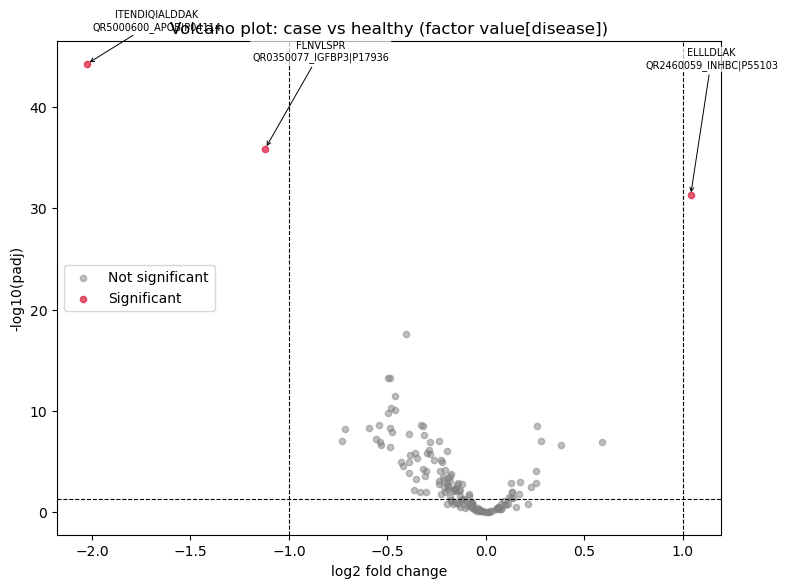

In [96]:
# Show volcano plot
de.plot_volcano()

(<Figure size 2800x800 with 5 Axes>, <Figure size 1800x110 with 1 Axes>)

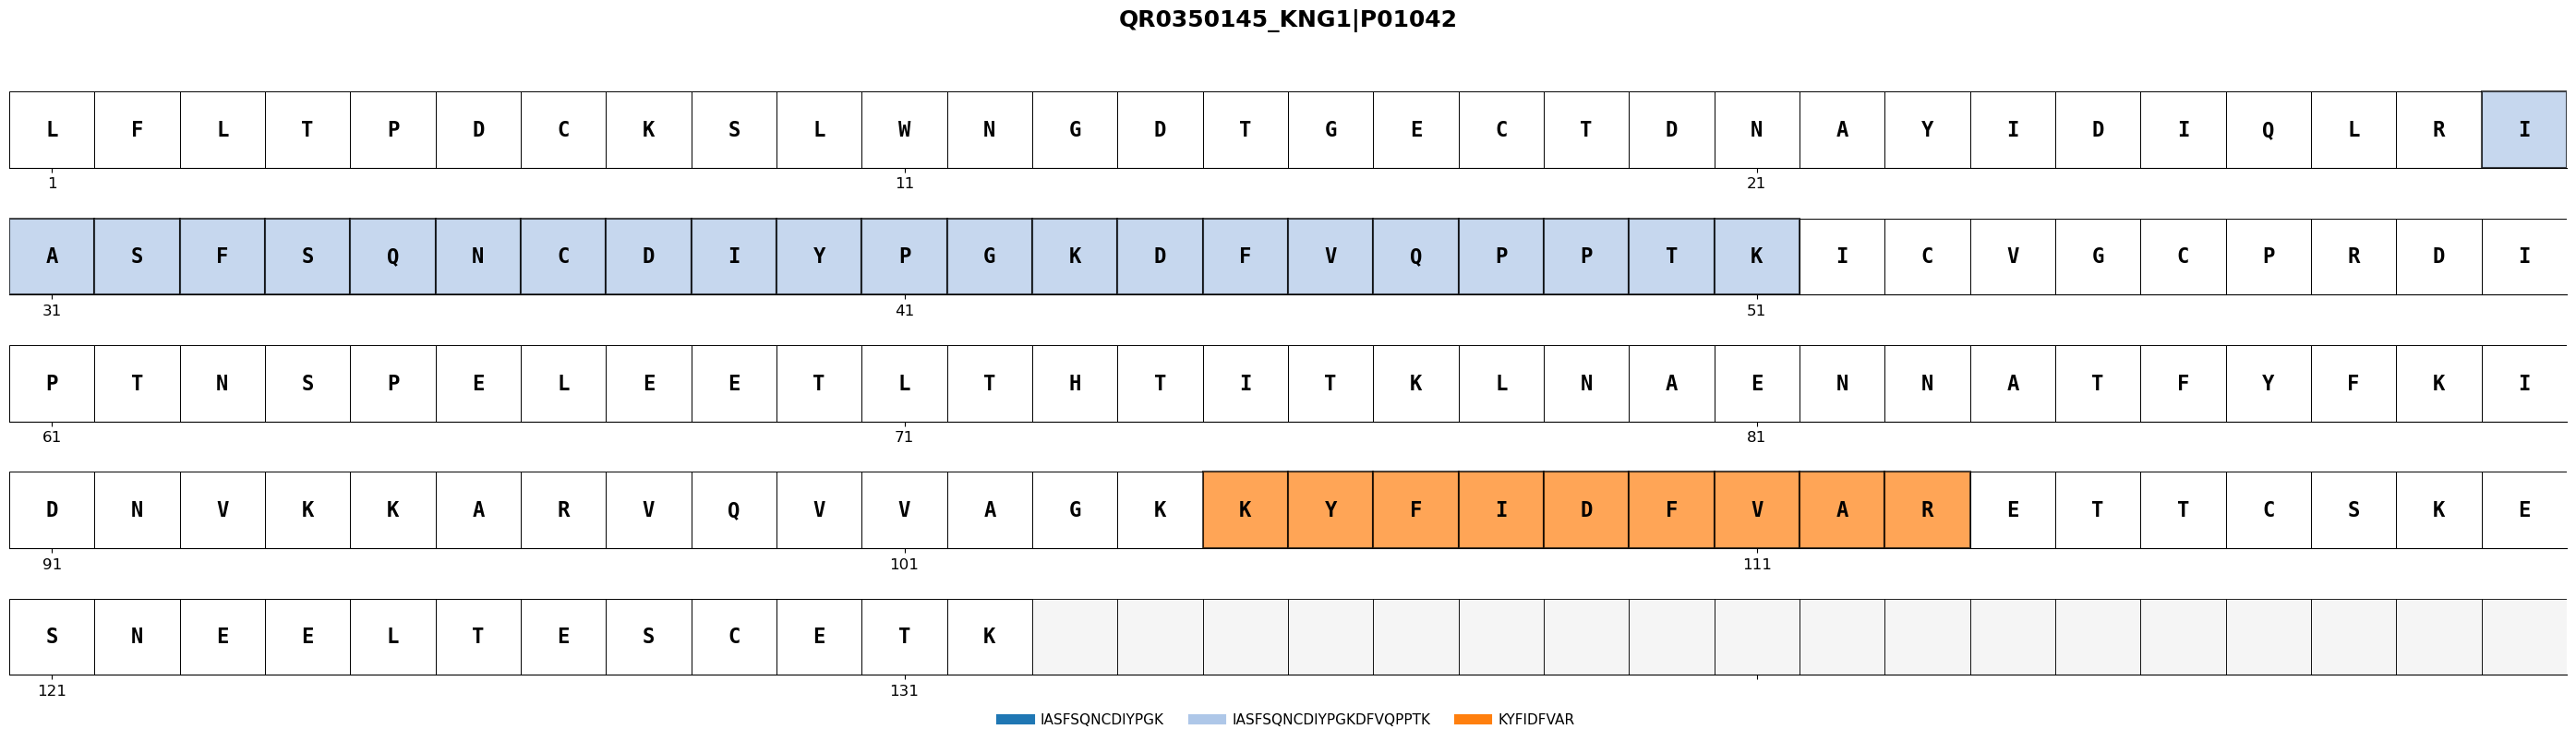

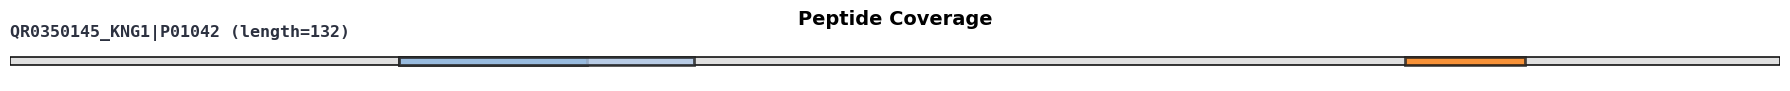

In [97]:
kdm.map_peptide_sequence(abs_df, fasta_file, 'QR0350145_KNG1|P01042')

In [98]:
kdm.plot_median_peptide_concentration_by_group(
    abs_df,
    sdrf_data_file,
    protein_name="QR0330186_VWF|P04275",
)

No data found for Protein Name: 'QR0330186_VWF|P04275'


In [99]:
kdm.plot_peptide_concentration_by_group(
    abs_df,
    sdrf_data_file,
    color_col='characteristics[disease category]',
    protein_name="QR0290109_EGFR|P00533",
)

No data found for Protein Name: 'QR0290109_EGFR|P00533'


In [100]:
kdm.plot_peptide_all(
    abs_df,
    sdrf_data_file,
    color_col='characteristics[disease category]',
    protein_name="QR0290109_EGFR|P00533",
)

No data found for Protein Name: 'QR0290109_EGFR|P00533'


/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:1909: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


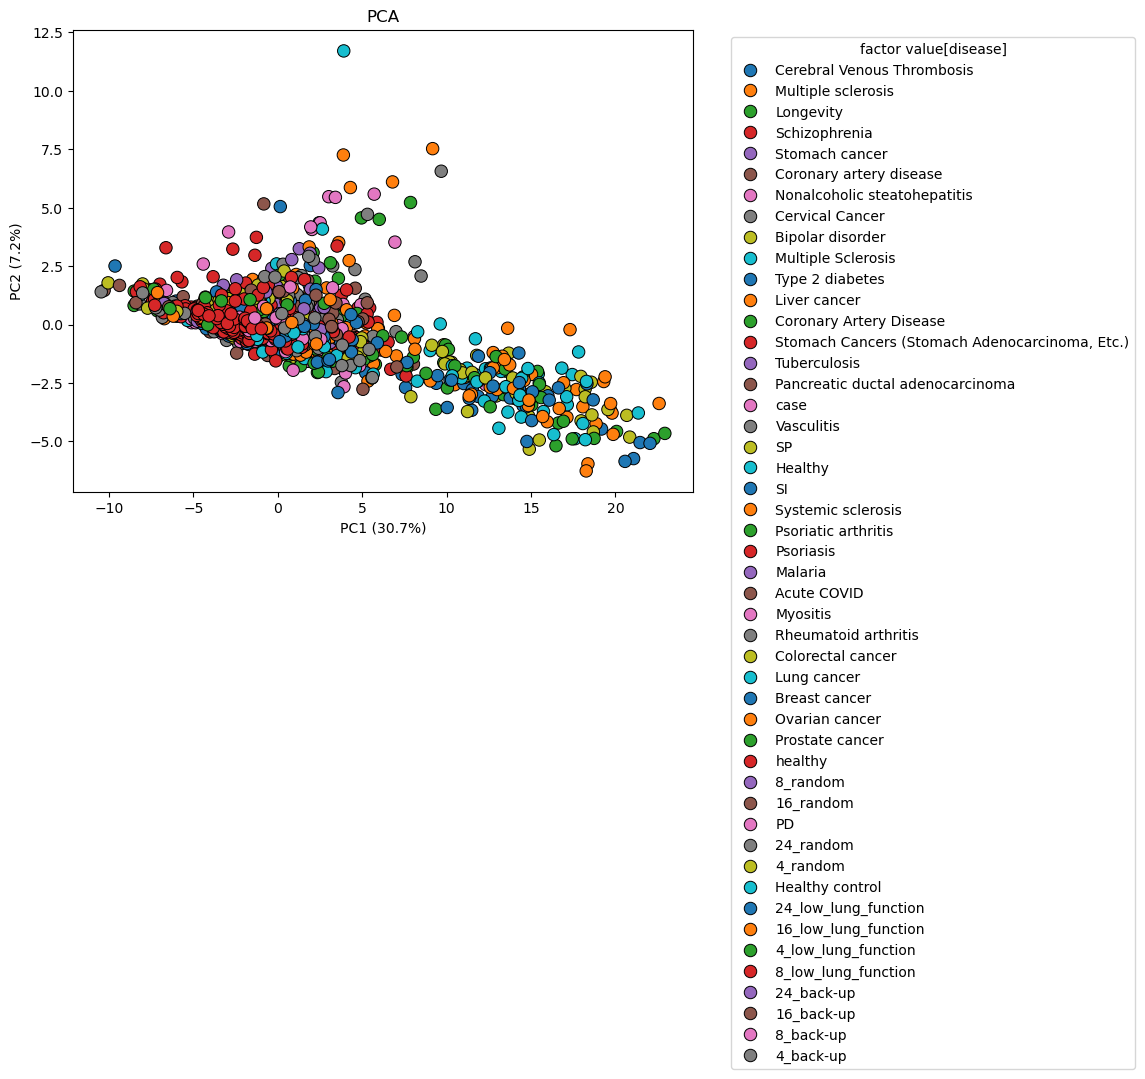

In [101]:
kdm.plot_pca(
    abs_df,
    sdrf_data_file
    
)

/home/thanadol/Documents/GitHub/kardemumma/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:1989: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


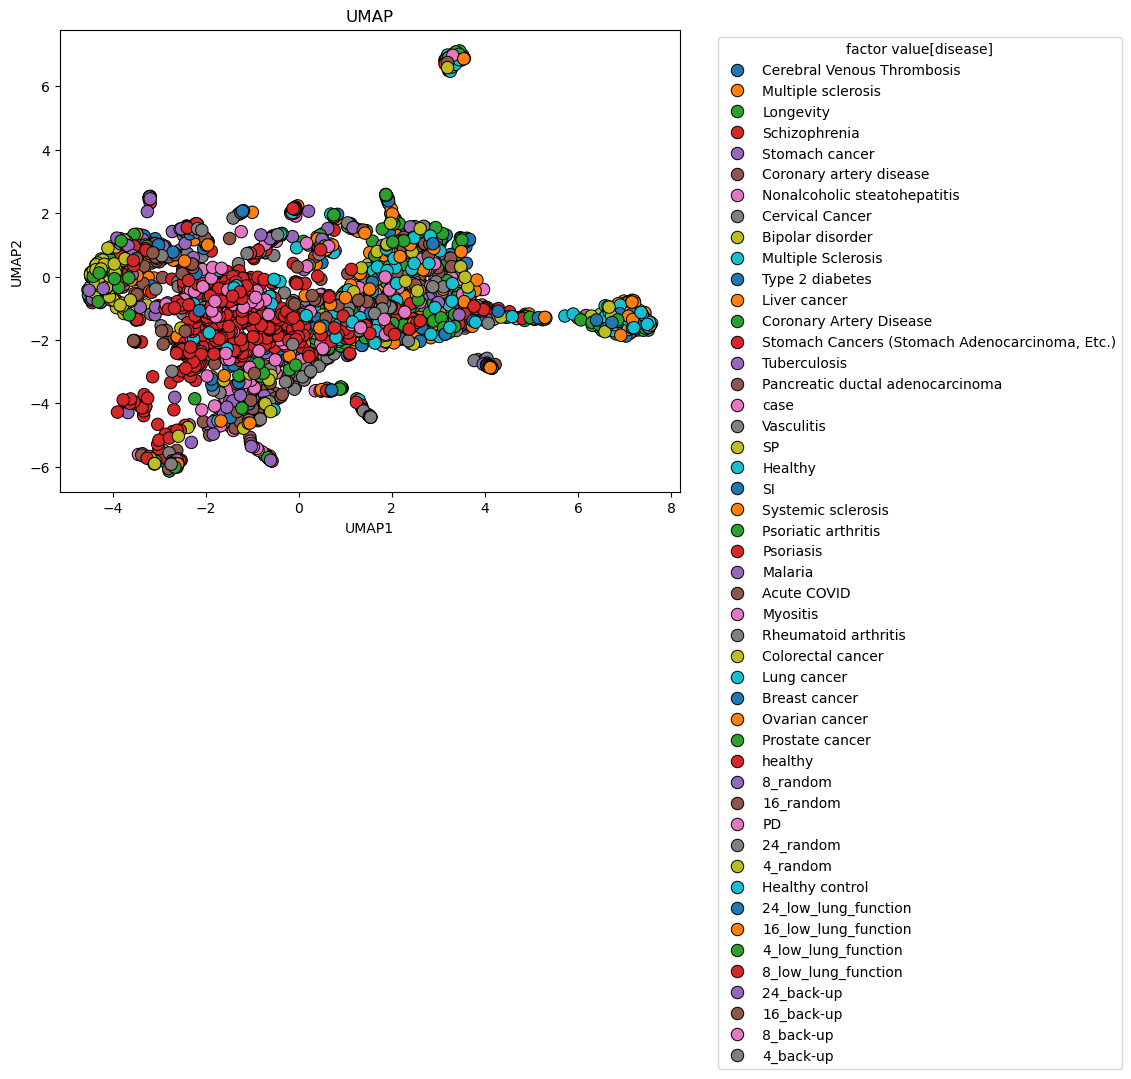

In [102]:
kdm.plot_umap(
    abs_df,
    sdrf_data_file
)
